<a href="https://colab.research.google.com/github/OJB-Quantum/Navaho-Linguistics/blob/main/Python%20Scripts%20for%20Navaho%20Linguistics/Quantum_Mechanics_Introduction_in_Navajo_Braille.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
# Install necessary libraries
!uv pip install gdstk ezdxf matplotlib

Successfully exported structural geometry to navajo_braille.dxf


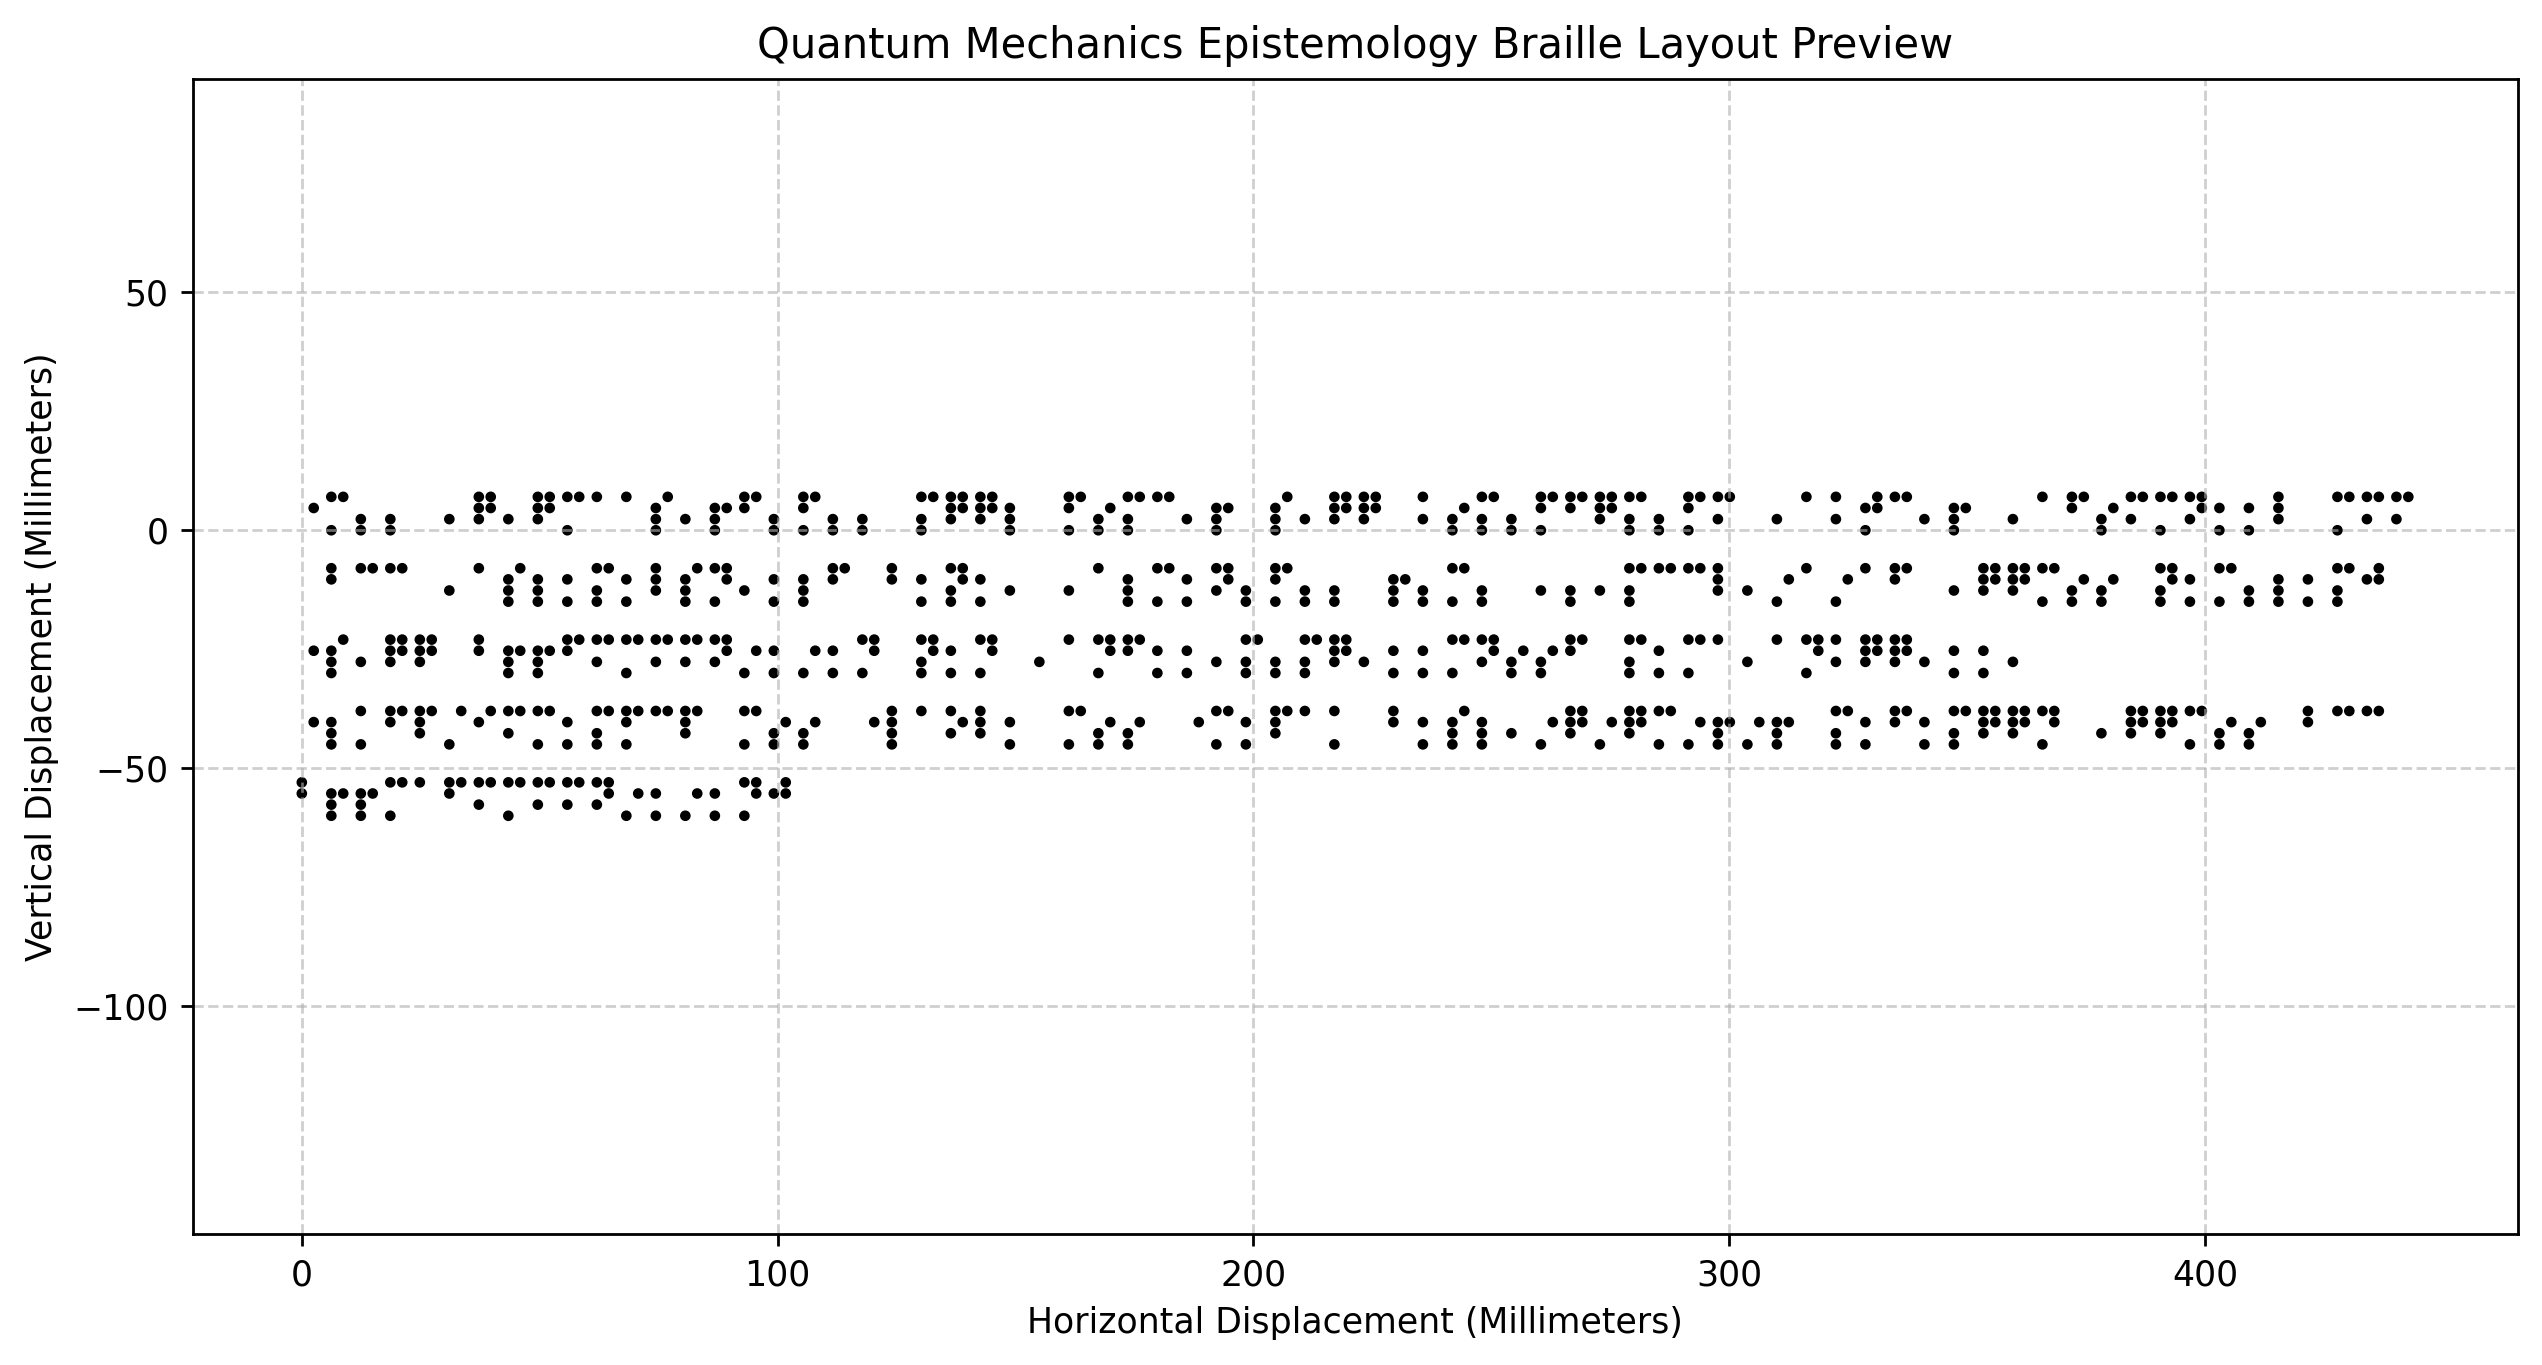

In [8]:
"""This script generates a structural layout of Braille dots corresponding to Navajo text using the Graphic Data System Toolkit (GDSTK) and Matplotlib.

It translates Unicode Braille characters into Euclidean spatial coordinates, which are subsequently
rendered for visual inspection within a notebook environment, incorporating expanded vertical
spacing for three dimensional physical printing applications.
"""

import gdstk
import ezdxf
import matplotlib.pyplot as plt
import matplotlib
from typing import List, Tuple

# =============================================================================
# Control Knobs
# =============================================================================
ENABLE_DXF_EXPORT = True
DXF_FILENAME = "navajo_braille.dxf" # Drawing Exchange Format (DXF)

# Visualization Parameters
FIGURE_DPI = 250  # Dots Per Inch (DPI)
PLOT_FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']
PLOT_FONT_WEIGHT = 'normal'

# Geometric Constants
DOT_DIAMETER = 1.5  # Millimeters
DOT_RADIUS = DOT_DIAMETER / 2.0
DOT_SPACING_V = 2.34  # Vertical distance between dots in a single cell (Millimeters)
DOT_SPACING_H = 2.5   # Horizontal distance between dots in a single cell (Millimeters)
CELL_SPACING_H = 6.2  # Distance between corresponding cells (Millimeters)
LINE_SPACING_V = 15.0 # Distance between corresponding lines (Millimeters) expanded for tactile physical testing

# Apply Matplotlib Configuration
matplotlib.rcParams['figure.dpi'] = FIGURE_DPI
matplotlib.rcParams['font.sans-serif'] = PLOT_FONT_SANS_SERIF
matplotlib.rcParams['font.weight'] = PLOT_FONT_WEIGHT

# Mapping of Braille Unicode bits to relative spatial coordinates (x, y)
BRAILLE_DOT_MAP = [
    (0.0, 3.0 * DOT_SPACING_V),              # Dot 1
    (0.0, 2.0 * DOT_SPACING_V),              # Dot 2
    (0.0, 1.0 * DOT_SPACING_V),              # Dot 3
    (0.0, 0.0),                              # Dot 4
    (DOT_SPACING_H, 3.0 * DOT_SPACING_V),    # Dot 5
    (DOT_SPACING_H, 2.0 * DOT_SPACING_V),    # Dot 6
    (DOT_SPACING_H, 1.0 * DOT_SPACING_V),    # Dot 7
    (DOT_SPACING_H, 0.0),                    # Dot 8
]

def get_braille_dots(char: str) -> List[Tuple[float, float]]:
    """Calculates the precise Euclidean coordinates of the individual dots for a given Braille character.

    Args:
        char: A single Braille Unicode character string.

    Returns:
        A list of floating-point coordinate tuples representing the geometric centers of the spatial dots.
    """
    codepoint = ord(char)
    if codepoint < 0x2800 or codepoint > 0x28FF:
        return []

    pattern = codepoint - 0x2800
    dots = []
    for i in range(8):
        if (pattern >> i) & 1:
            dots.append(BRAILLE_DOT_MAP[i])
    return dots

class BrailleLayout:
    """Constructs a spatial layout of Braille characters utilizing structural cells and robust geometry."""

    def __init__(self, text: str):
        """Initializes the structural layout environment with the provided input sequence.

        Args:
            text: The continuous string sequence containing valid Braille characters.
        """
        self.text = text
        self.library = gdstk.Library()
        self.main_cell = self.library.new_cell("MAIN")

    def generate(self) -> None:
        """Processes the input text array and instantiates geometric primitives within the primary cell."""
        lines = self.text.split('\n')

        for row_idx, line in enumerate(lines):
            for col_idx, char in enumerate(line):
                offset_x = col_idx * CELL_SPACING_H
                offset_y = -row_idx * LINE_SPACING_V

                dots = get_braille_dots(char)
                for dx, dy in dots:
                    # Utilizing robust polygon representation for circular geometry in Graphic Data System Toolkit (GDSTK)
                    circle_polygon = gdstk.regular_polygon((offset_x + dx, offset_y + dy), DOT_RADIUS, 64)
                    self.main_cell.add(circle_polygon)

    def export_dxf(self, filename: str) -> None:
        """Translates internal geometry to a Drawing Exchange Format (DXF) document and writes to local disk.

        Args:
            filename: The string identifier for the exported file.
        """
        doc = ezdxf.new()
        msp = doc.modelspace()

        for polygon in self.main_cell.polygons:
            # Calculate the geometric center dynamically from the robust bounding box
            bbox = polygon.bounding_box()
            center_x = (bbox[0][0] + bbox[1][0]) / 2.0
            center_y = (bbox[0][1] + bbox[1][1]) / 2.0
            msp.add_circle((center_x, center_y), DOT_RADIUS)

        doc.saveas(filename)
        print(f"Successfully exported structural geometry to {filename}")

    def render_preview(self) -> None:
        """Renders the spatial dots inline utilizing Matplotlib for visual notebook confirmation."""
        plt.figure(figsize=(12, 6))

        for polygon in self.main_cell.polygons:
            bbox = polygon.bounding_box()
            center_x = (bbox[0][0] + bbox[1][0]) / 2.0
            center_y = (bbox[0][1] + bbox[1][1]) / 2.0
            circle = plt.Circle((center_x, center_y), DOT_RADIUS, color='black')
            plt.gca().add_patch(circle)

        plt.axis('equal')
        plt.title("Quantum Mechanics Epistemology Braille Layout Preview")
        plt.xlabel("Horizontal Displacement (Millimeters)")
        plt.ylabel("Vertical Displacement (Millimeters)")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

if __name__ == "__main__":
    navajo_braille_text = (
        "⠠⠙⠌⠌ ⠄⠷⠄⠷⠙⠁⠁⠞⠄⠮⠓⠌⠛⠌⠌ ⠝⠷⠷⠎ ⠛⠬⠝⠑⠄⠮ ⠞⠄⠷⠷ ⠅⠬⠝⠌⠛⠓⠷⠝⠌⠛⠕ ⠄⠁⠅⠺⠑⠄⠮ ⠄⠁⠓⠬⠕⠙⠵⠊⠊⠇ ⠙⠕⠕\n"
        " ⠃⠑⠑ ⠄⠁⠞⠎⠊⠝⠊⠇⠞⠹⠄⠊⠎⠓ ⠃⠊⠽⠊⠄ ⠄⠁⠎⠙⠊⠵⠌⠛⠌⠌ ⠮⠌⠙⠌ ⠄⠌⠄⠝⠑⠑⠇⠄⠨⠁⠨⠁⠓ ⠄⠷⠷⠙⠬⠬ ⠽⠊⠙⠌⠎⠊⠝⠲ \n"
        "⠠⠞⠄⠷⠷ ⠃⠮⠮⠓⠕⠙⠕⠕⠵⠨⠊⠨⠊⠹ ⠽⠊⠹ ⠄⠁⠹⠓⠊⠊⠄⠝⠌⠝⠷⠄⠊⠊⠙⠵⠬⠬⠓ ⠝⠊⠙⠁⠄⠁⠹⠅⠷⠷⠄⠊⠊⠄ \n"
        "⠠⠎⠉⠓⠗⠘⠒⠕⠙⠊⠝⠛⠑⠗ ⠙⠬⠬ ⠠⠏⠁⠥⠇⠊ ⠙⠬⠬ ⠠⠙⠊⠗⠁⠉ ⠃⠊⠞⠎⠄⠨⠷⠨⠷⠙⠨⠮⠨⠮ ⠝⠊⠓⠊⠝⠷⠷⠹ ⠄⠷⠷⠙⠬⠬ ⠃⠑⠑ \n"
        "⠃⠮⠮⠙⠁⠓⠕⠙⠕⠕⠵⠨⠊⠨⠊⠹⠲"
    )

    layout = BrailleLayout(navajo_braille_text)
    layout.generate()

    if ENABLE_DXF_EXPORT:
        layout.export_dxf(DXF_FILENAME)

    layout.render_preview()